In [1]:
# !pip install -U sentence-transformers yfinance torch

import numpy as np
import pandas as pd
import yfinance as yf
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from itertools import product

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [2]:
# ============================================================
# Load and preprocess news headline data
# ============================================================

news = pd.read_csv("Combined_News_DJIA.csv")
news["Date"] = pd.to_datetime(news["Date"])

headline_cols = [c for c in news.columns if c.startswith("Top")]
news_long = news.melt(
    id_vars="Date",
    value_vars=headline_cols,
    var_name="headline_rank",
    value_name="headline"
).dropna()

print("News long shape:", news_long.shape)
print(news_long.head())

News long shape: (49718, 3)
        Date headline_rank                                           headline
0 2008-08-08          Top1  b"Georgia 'downs two Russian warplanes' as cou...
1 2008-08-11          Top1  b'Why wont America and Nato help us? If they w...
2 2008-08-12          Top1  b'Remember that adorable 9-year-old who sang a...
3 2008-08-13          Top1  b' U.S. refuses Israel weapons to attack Iran:...
4 2008-08-14          Top1  b'All the experts admit that we should legalis...


In [3]:
# ============================================================
# Load sector ETF price data
# ============================================================

sector_tickers = [
    "XLE","XLF","XLV","XLK","XLY","XLP",
    "XLI","XLB","XLU"
]

start_date = "2008-08-08"
end_date = "2016-07-01"

data = yf.download(
    tickers=sector_tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True,
    progress=False
)

adj_close = data["Close"]
volume = data["Volume"]

adj_close.index = pd.to_datetime(adj_close.index)

common_dates = adj_close.index.intersection(news["Date"])
adj_close = adj_close.loc[common_dates]
volume = volume.loc[common_dates]
news_long = news_long[news_long["Date"].isin(common_dates)]

print("Adj_close shape after align:", adj_close.shape)
print("News_long shape after align:", news_long.shape)

Adj_close shape after align: (1988, 9)
News_long shape after align: (49693, 3)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

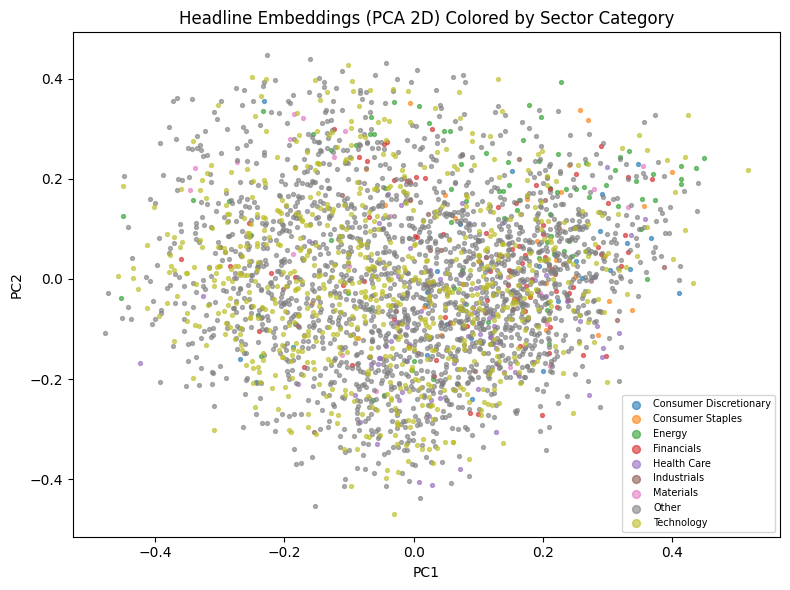

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


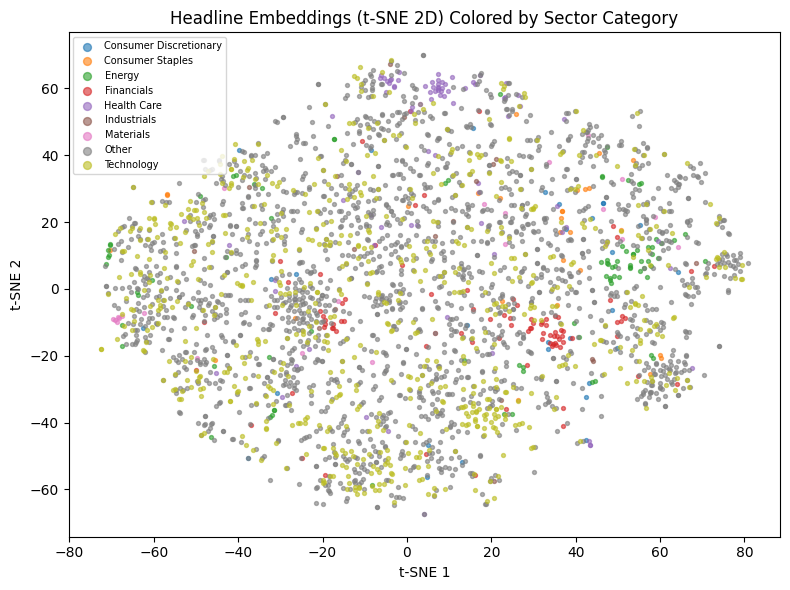

In [4]:
# ============================================================
# Visualize headline embeddings via PCA / t-SNE
# ============================================================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

enc_model_name = "sentence-transformers/all-MiniLM-L6-v2"
enc_model = SentenceTransformer(enc_model_name)

# --- 1) Sample a manageable subset of headlines ---
sample_size = 3000
news_sample = news_long.dropna(subset=["headline"]).sample(
    n=min(sample_size, len(news_long)),
    random_state=42
).reset_index(drop=True)

# --- 2) Sector-relevant headline categorization ---
# These are heuristic keyword sets that often map well to S&P sectors.
def categorize_headline(text):
    t = text.lower()

    if any(k in t for k in [
        "consumer", "retail", "amazon", "nike", "mcdonald", "travel", "auto", "tesla", "restaurant", "apparel"
    ]):
        return "Consumer Discretionary"

    if any(k in t for k in [
        "food", "beverage", "staple", "procter", "walmart", "costco", "household", "grocery"
    ]):
        return "Consumer Staples"

    if any(k in t for k in [
        "oil", "gas", "energy", "opec", "shale", "drilling", "refinery", "exxon", "chevron"
    ]):
        return "Energy"

    if any(k in t for k in [
        "bank", "loan", "credit", "interest rate", "fed", "treasury", "bond", "mortgage",
        "goldman", "jpmorgan"
    ]):
        return "Financials"

    if any(k in t for k in [
        "health", "pharma", "drug", "biotech", "vaccine", "medical", "hospital", "fda"
    ]):
        return "Health Care"

    if any(k in t for k in [
        "industry", "manufacturing", "airline", "transport", "construction", "machinery", "boeing", "caterpillar"
    ]):
        return "Industrials"

    if any(k in t for k in [
        "material", "mining", "metal", "chemical", "steel", "copper", "lithium"
    ]):
        return "Materials"

    if any(k in t for k in [
        "tech", "software", "chip", "semiconductor", "apple", "google", "microsoft",
        "intel", "cloud", "ai", "cyber"
    ]):
        return "Technology"

    return "Other"

news_sample["category"] = news_sample["headline"].astype(str).apply(categorize_headline)

# --- 3) Compute embeddings for these individual headlines ---
headline_embs = enc_model.encode(
    news_sample["headline"].tolist(),
    batch_size=64,
    show_progress_bar=True
)
headline_embs = np.array(headline_embs)

# --- 4) PCA (2 components) ---
pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(headline_embs)

plt.figure(figsize=(8, 6))
for cat in sorted(news_sample["category"].unique()):
    mask = news_sample["category"] == cat
    plt.scatter(
        emb_pca[mask, 0],
        emb_pca[mask, 1],
        s=8,
        alpha=0.6,
        label=cat
    )
plt.title("Headline Embeddings (PCA 2D) Colored by Sector Category")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2, fontsize=7)
plt.tight_layout()
plt.show()

# --- 5) t-SNE (nonlinear—often more interpretable clusters) ---
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1500,
    random_state=42,
    init="pca"
)
emb_tsne = tsne.fit_transform(headline_embs)

plt.figure(figsize=(8, 6))
for cat in sorted(news_sample["category"].unique()):
    mask = news_sample["category"] == cat
    plt.scatter(
        emb_tsne[mask, 0],
        emb_tsne[mask, 1],
        s=8,
        alpha=0.6,
        label=cat
    )
plt.title("Headline Embeddings (t-SNE 2D) Colored by Sector Category")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(markerscale=2, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# ===========================================================================
# Build daily news embeddings via SentenceTransformer, add recency smoothing
# ===========================================================================

daily_embeddings = {}
for date, group in news_long.groupby("Date"):
    headlines = group["headline"].tolist()
    emb = enc_model.encode(headlines, batch_size=32, show_progress_bar=False)
    daily_embeddings[date] = emb.mean(axis=0)

emb_df = pd.DataFrame.from_dict(daily_embeddings, orient="index")
emb_df.index.name = "Date"
emb_df.sort_index(inplace=True)

alpha = 0.9
emb_smooth = emb_df.copy()
for i in range(1, len(emb_smooth)):
    emb_smooth.iloc[i] = alpha * emb_smooth.iloc[i] + (1 - alpha) * emb_smooth.iloc[i-1]

# emb_smooth = emb_df.copy()

In [ ]:
# ================================================================
# Numeric features: returns, vol, moving averages, vol z-score
# ================================================================

returns = np.log(adj_close / adj_close.shift(1))
returns = returns.dropna()

roll_win = 20
vol_20 = returns.rolling(roll_win).std()
ma_10 = adj_close.rolling(10).mean() / adj_close - 1
ma_50 = adj_close.rolling(50).mean() / adj_close - 1
vol_z = (volume - volume.rolling(60).mean()) / volume.rolling(60).std()

features_dates = returns.index.intersection(emb_smooth.index)

returns = returns.loc[features_dates]
vol_20 = vol_20.loc[features_dates]
ma_10 = ma_10.loc[features_dates]
ma_50 = ma_50.loc[features_dates]
vol_z = vol_z.loc[features_dates]
emb_smooth = emb_smooth.loc[features_dates]

target_horizon = 1
y_next = returns.shift(-target_horizon)

In [ ]:
# ============================================================
# Drop dates with NaN values
# ============================================================

combined = pd.concat(
    [
        returns.add_prefix("ret_"),
        vol_20.add_prefix("vol20_"),
        ma_10.add_prefix("ma10_"),
        ma_50.add_prefix("ma50_"),
        vol_z.add_prefix("volz_"),
        emb_smooth,
    ],
    axis=1
)

combined = combined.replace([np.inf, -np.inf], np.nan).dropna()
clean_dates = combined.index

returns    = returns.loc[clean_dates]
vol_20     = vol_20.loc[clean_dates]
ma_10      = ma_10.loc[clean_dates]
ma_50      = ma_50.loc[clean_dates]
vol_z      = vol_z.loc[clean_dates]
emb_smooth = emb_smooth.loc[clean_dates]
y_next     = y_next.loc[clean_dates]

dates = clean_dates
print("Number of clean dates:", len(dates))

Number of clean dates: 1929


In [ ]:
# ============================================================
# Build training dataset X, and direction labels y (0/1)
# ============================================================

L = 20

X_list = []
y_list = []

for i in range(L, len(dates) - target_horizon):
    t = dates[i]
    t_prev = dates[i-L:i]

    text_feat = emb_smooth.loc[t].values

    for s in sector_tickers:
        num_feats = []
        num_feats.append(returns[s].loc[t_prev].values)
        num_feats.append(vol_20[s].loc[t_prev].values)
        num_feats.append(ma_10[s].loc[t_prev].values)
        num_feats.append(ma_50[s].loc[t_prev].values)
        num_feats.append(vol_z[s].loc[t_prev].values)
        num_feats = np.concatenate(num_feats, axis=0)

        x = np.concatenate([num_feats, text_feat], axis=0)
        X_list.append(x)

        next_ret = y_next[s].loc[t]
        label = 1.0 if next_ret > 0 else 0.0
        y_list.append(label)

X = np.stack(X_list)
y = np.array(y_list, dtype=float)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive class fraction:", y.mean())

X shape: (17172, 484)
y shape: (17172,)
Positive class fraction: 0.5368623340321453


In [ ]:
# ==============================================================
# Split into numeric-only vs numeric+headlines; scale features
# ==============================================================

text_dim = emb_smooth.shape[1] # should be 384
numeric_dim = X.shape[1] - text_dim # should be 100

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_with_text = X_scaled
X_num_only  = X_scaled[:, :numeric_dim]

print("Numeric-only dim:", X_num_only.shape[1])
print("With-text dim:", X_with_text.shape[1])

Numeric-only dim: 100
With-text dim: 484


In [ ]:
# ============================================================
# Train/val split
# ============================================================

N = len(X_scaled)
split_idx = int(0.8 * N)
train_idx = np.arange(0, split_idx)
val_idx   = np.arange(split_idx, N)

def make_loaders(X_array, y_array, batch_size=256):
    X_t = torch.tensor(X_array, dtype=torch.float32)
    y_t = torch.tensor(y_array, dtype=torch.float32).unsqueeze(1)

    X_train, X_val = X_t[train_idx], X_t[val_idx]
    y_train, y_val = y_t[train_idx], y_t[val_idx]

    train_ds = TensorDataset(X_train, y_train)
    val_ds   = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

In [ ]:
# ============================================================
# Model definition & training helper
# ============================================================

class DirectionPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, hidden_dim2=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, 1)
        )
    def forward(self, x):
        return self.net(x)


def train_model(
    model,
    train_loader,
    val_loader,
    n_epochs=30,
    lr=1e-4,
):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def eval_loader(loader):
        model.eval()
        total_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                total_loss += loss.item() * xb.size(0)

                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                correct += (preds == yb).sum().item()
                total += xb.size(0)

        return total_loss / total, correct / total

    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = eval_loader(train_loader)
        val_loss, val_acc     = eval_loader(val_loader)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {
                "model": model.state_dict(),
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_acc": val_acc,
            }

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.6e} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.6e} | val_acc={val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state["model"])
        return model, best_state
    else:
        final_loss, final_acc = eval_loader(val_loader)
        return model, {
            "model": model.state_dict(),
            "epoch": n_epochs,
            "train_loss": None,
            "val_loss": final_loss,
            "val_acc": final_acc,
        }

In [ ]:
# ============================================================
# Grid search helper function
# ============================================================

def grid_search_direction(
    X_array,
    y_array,
    model_name="numeric-only",
    hidden_dims=(64, 128),
    hidden_dims2=(32, 64),
    dropouts=(0.2, 0.3),
    lrs=(1e-3, 1e-4),
    epoch_options=(30, 60),
    batch_sizes=(256,),
):
    print(f"\n=== Grid search for {model_name} model ===")

    train_loader_base = None
    val_loader_base   = None

    results = []
    input_dim = X_array.shape[1]
    for hidden_dim, hidden_dim2, dropout, lr, n_epochs, batch_size in product(
        hidden_dims, hidden_dims2, dropouts, lrs, epoch_options, batch_sizes
    ):
        print("\nConfig:",
              f"hidden_dim={hidden_dim}, hidden_dim2={hidden_dim2}, "
              f"dropout={dropout}, lr={lr}, epochs={n_epochs}, batch={batch_size}")

        train_loader, val_loader = make_loaders(X_array, y_array, batch_size=batch_size)

        model = DirectionPredictor(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            hidden_dim2=hidden_dim2,
            dropout=dropout,
        )

        model, best_state = train_model(
            model,
            train_loader,
            val_loader,
            n_epochs=n_epochs,
            lr=lr,
        )

        results.append({
            "hidden_dim": hidden_dim,
            "hidden_dim2": hidden_dim2,
            "dropout": dropout,
            "lr": lr,
            "epochs": best_state["epoch"],
            "batch_size": batch_size,
            "val_loss": best_state["val_loss"],
            "val_acc": best_state["val_acc"],
        })

        print(
            f"Best for this config -> epoch={best_state['epoch']}, "
            f"val_loss={best_state['val_loss']:.6e}, val_acc={best_state['val_acc']:.4f}"
        )

    results_df = pd.DataFrame(results)
    best_row = results_df.sort_values("val_acc", ascending=False).iloc[0]
    print(f"\n=== Best {model_name} config by val_acc ===")
    print(best_row)

    return results_df, best_row

In [ ]:
# ============================================================
# Grid search: numeric-only vs numeric+text
# ============================================================

results_num, best_num = grid_search_direction(
    X_num_only,
    y,
    model_name="numeric-only",
    hidden_dims=(64, 128),
    hidden_dims2=(32, 64),
    dropouts=(0.2, 0.3),
    lrs=(1e-3, 1e-4),
    epoch_options=(30, 60),
    batch_sizes=(256,),
)

results_txt, best_txt = grid_search_direction(
    X_with_text,
    y,
    model_name="numeric+text",
    hidden_dims=(64, 128),
    hidden_dims2=(32, 64),
    dropouts=(0.2, 0.3),
    lrs=(1e-3, 1e-4),
    epoch_options=(30, 60),
    batch_sizes=(256,),
)

print("\n=== Summary: best configs ===")
print("Numeric-only best:\n", best_num)
print("\nNumeric+text best:\n", best_txt)
print("\nAccuracy improvement (txt - num):",
      float(best_txt["val_acc"] - best_num["val_acc"]))


=== Grid search for numeric-only model ===

Config: hidden_dim=64, hidden_dim2=32, dropout=0.2, lr=0.001, epochs=30, batch=256
Epoch 01 | train_loss=6.861082e-01 | train_acc=0.5469 | val_loss=6.960732e-01 | val_acc=0.5135
Epoch 02 | train_loss=6.824918e-01 | train_acc=0.5570 | val_loss=6.967043e-01 | val_acc=0.5191
Epoch 03 | train_loss=6.773385e-01 | train_acc=0.5739 | val_loss=6.991236e-01 | val_acc=0.5132
Epoch 04 | train_loss=6.729329e-01 | train_acc=0.5756 | val_loss=7.036721e-01 | val_acc=0.5109
Epoch 05 | train_loss=6.694373e-01 | train_acc=0.5822 | val_loss=7.028334e-01 | val_acc=0.5150
Epoch 06 | train_loss=6.629774e-01 | train_acc=0.5973 | val_loss=7.105022e-01 | val_acc=0.5048
Epoch 07 | train_loss=6.561951e-01 | train_acc=0.6074 | val_loss=7.079391e-01 | val_acc=0.5057
Epoch 08 | train_loss=6.490989e-01 | train_acc=0.6196 | val_loss=7.098977e-01 | val_acc=0.5025
Epoch 09 | train_loss=6.436676e-01 | train_acc=0.6173 | val_loss=7.211006e-01 | val_acc=0.5048
Epoch 10 | train_


========================================

OG structure, OG lr (1e-3):

=== Final comparison (direction) ===
Numeric-only   -> val_loss=1.325626e+00, val_acc=0.4926
Numeric+text   -> val_loss=1.689458e+00, val_acc=0.4984
Accuracy improvement: +0.0058

========================================

OG structure, 1e-4 lr:

=== Final comparison (direction) ===

Numeric-only -> val_loss=7.693495e-01, val_acc=0.4946
Numeric+text -> val_loss=1.167111e+00, val_acc=0.5013

Accuracy improvement: +0.0067

========================================




In [ ]:
# ============================================================
# NN Sandbox: For quick testing of different params
# ============================================================

hidden_dim   = 1024
hidden_dim2  = 256
dropout      = 0.3
lr           = 1e-5
n_epochs     = 60
batch_size   = 256


class SimpleDirectionNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, hidden_dim2=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, 1),
        )

    def forward(self, x):
        return self.net(x)


def make_loaders_simple(X_array, y_array, batch_size=256):
    X_t = torch.tensor(X_array, dtype=torch.float32)
    y_t = torch.tensor(y_array, dtype=torch.float32).unsqueeze(1)

    X_train, X_val = X_t[train_idx], X_t[val_idx]
    y_train, y_val = y_t[train_idx], y_t[val_idx]

    train_ds = TensorDataset(X_train, y_train)
    val_ds = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def train_and_eval(X_array, y_array, label="model"):
    input_dim = X_array.shape[1]
    train_loader, val_loader = make_loaders_simple(X_array, y_array, batch_size=batch_size)

    model = SimpleDirectionNet(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        hidden_dim2=hidden_dim2,
        dropout=dropout,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def eval_loader(loader):
        model.eval()
        total_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                total_loss += loss.item() * xb.size(0)

                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                correct += (preds == yb).sum().item()
                total += xb.size(0)

        return total_loss / total, correct / total

    print(f"\n=== Training {label} ===")
    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = eval_loader(train_loader)
        val_loss, val_acc     = eval_loader(val_loader)
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    val_loss, val_acc = eval_loader(val_loader)
    print(f"\nFinal {label} -> val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    return model, (val_loss, val_acc)


# 1) Numeric-only
model_num, metrics_num = train_and_eval(X_num_only, y, label="numeric-only")

# 2) Numeric + headlines
model_txt, metrics_txt = train_and_eval(X_with_text, y, label="numeric+text")

print("\n=== Comparison ===")
print("Numeric-only  val_acc:", metrics_num[1])
print("Numeric+text  val_acc:", metrics_txt[1])
print("Accuracy improvement (txt - num):", metrics_txt[1] - metrics_num[1])


=== Training numeric-only ===
Epoch 01 | train_loss=0.6897 | train_acc=0.5418 | val_loss=0.6938 | val_acc=0.5080
Epoch 02 | train_loss=0.6884 | train_acc=0.5421 | val_loss=0.6948 | val_acc=0.5127
Epoch 03 | train_loss=0.6877 | train_acc=0.5425 | val_loss=0.6955 | val_acc=0.5130
Epoch 04 | train_loss=0.6870 | train_acc=0.5434 | val_loss=0.6958 | val_acc=0.5132
Epoch 05 | train_loss=0.6864 | train_acc=0.5458 | val_loss=0.6961 | val_acc=0.5121
Epoch 06 | train_loss=0.6859 | train_acc=0.5471 | val_loss=0.6965 | val_acc=0.5121
Epoch 07 | train_loss=0.6853 | train_acc=0.5477 | val_loss=0.6968 | val_acc=0.5118
Epoch 08 | train_loss=0.6847 | train_acc=0.5503 | val_loss=0.6967 | val_acc=0.5132
Epoch 09 | train_loss=0.6843 | train_acc=0.5511 | val_loss=0.6971 | val_acc=0.5135
Epoch 10 | train_loss=0.6838 | train_acc=0.5530 | val_loss=0.6972 | val_acc=0.5135
Epoch 11 | train_loss=0.6833 | train_acc=0.5535 | val_loss=0.6975 | val_acc=0.5135
Epoch 12 | train_loss=0.6828 | train_acc=0.5548 | val_lo